# Cargar dataset Iris

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset Iris
iris = load_iris()
X, y = iris.data, iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("Forma del dataset:", df.shape)
print("Clases:", iris.target_names)
df.head()


Forma del dataset: (150, 5)
Clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#Aplicar metodo de ensamble con VotingClassifier

Precisión del Ensamble VotingClassifier: 0.9667


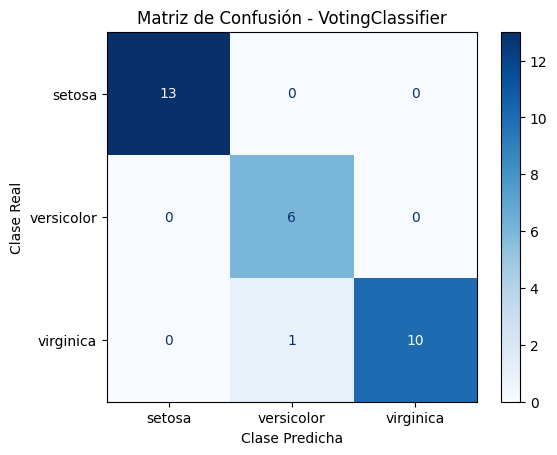

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Escalado
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Definimos los modelos base
clf1 = LogisticRegression(max_iter=200)
clf2 = DecisionTreeClassifier(random_state=123)
clf3 = KNeighborsClassifier(n_neighbors=5)

# Ensamble con votación mayoritaria
vot_clf = VotingClassifier(estimators=[
    ('lr', clf1),
    ('dt', clf2),
    ('knn', clf3)
], voting='soft')

# Entrenamiento
vot_clf.fit(X_train, y_train)

# Predicciones
y_pred = vot_clf.predict(X_test)

# Evaluación
acc = accuracy_score(y_test, y_pred)
print(f"Precisión del Ensamble VotingClassifier: {acc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - VotingClassifier")
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()


Interpretación: El VotingClassifier tiene una precisión excelente del $96.67\%$ en el conjunto de prueba, lo que confirma que el método de ensamble funcionó muy bien para esta tarea. El único punto de confusión fue una flor versicolor mal clasificada como virginica.

#Aplicar el algoritmo K-Means

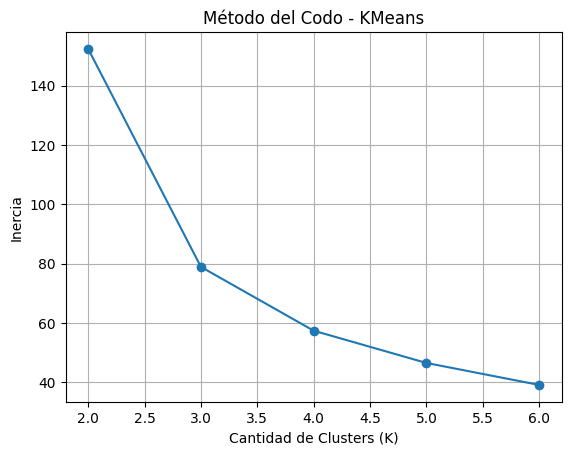

In [ ]:
from sklearn.cluster import KMeans

inercia = []
K_rango = range(2, 7)

for k in K_rango:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.plot(K_rango, inercia, marker='o')
plt.title("Método del Codo - KMeans")
plt.xlabel("Cantidad de Clusters (K)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


Basándose en la forma de la curva, el punto donde el descenso pasa de ser muy pronunciado a ser más gradual se encuentra en K=3.

#Reducción de Dimensionalidad con PCA

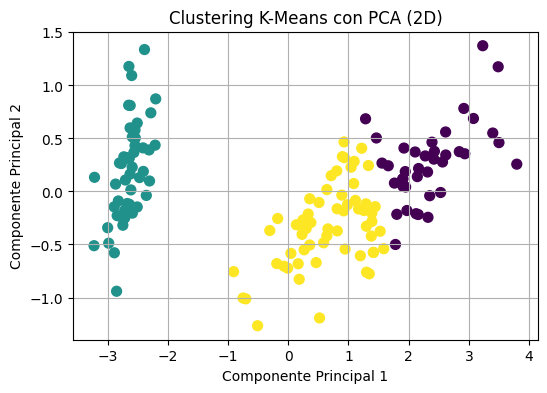


Comparacíon con las clases reales



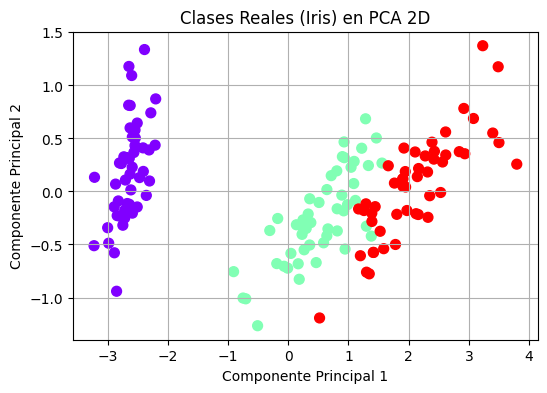

In [ ]:
from sklearn.decomposition import PCA

# Aplicamos PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Clustering con KMeans (K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Visualización
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=50)
plt.title("Clustering K-Means con PCA (2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

print("\nComparacíon con las clases reales\n")
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='rainbow', s=50)
plt.title("Clases Reales (Iris) en PCA 2D")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()


Los grupos obtenidos con el algoritmo K-Means coinciden en gran medida con las clases reales del dataset Iris. En particular, la clase setosa se separa de forma clara, mientras que versicolor y virginica presentan cierta superposición, lo cual es esperable dado que son parecidas en sus características.

La aplicación de PCA mejoró la visualización al reducir las dimensiones a 2 componentes principales, permitiendo observar de manera más clara la separación entre los grupos y facilitando la interpretación de los resultados del clustering.